# **Determination of Planck’s Constant Using the Photoelectric Effect**

This notebook documents the **Photoelectric Effect Experiment**, which investigates the relationship between the frequency of incident light and the stopping voltage required to prevent photoelectron emission.

### **Objectives:**
- Verify Einstein’s photoelectric equation.
- Determine the stopping voltage for different wavelengths.
- Calculate Planck’s constant \( h \) using experimental data.


## **Theoretical Background**
The **photoelectric effect** occurs when light of sufficient frequency illuminates a metal surface, causing the emission of electrons (photoelectrons). According to Einstein’s equation:

$$ e U_f = h f - W $$

where:
- \( e \) is the electron charge (\( $1.602 \times 10^{-19} C$ \))
- \( $U_f$ \) is the stopping voltage
- \( h \) is Planck’s constant
- \( f \) is the frequency of the incident light
- \( W \) is the work function of the metal (minimum energy required to emit an electron)

By plotting **stopping voltage** \( $U_f$ \) vs **frequency** \( f \), we obtain a straight line with slope:

$$ \text{slope} = \frac{h}{e} $$

From this, Planck’s constant can be determined experimentally.

## **Experimental Setup**

![Photoelectric Effect Setup](imgs/image.png)
![Photoelectric Effect Setup2](imgs/image1.png)

The experimental apparatus consists of:
- A **mercury discharge lamp** as the monochromatic light source.
- A **set of optical filters** to select specific frequencies.
- A **photoelectric cell** with a metal cathode.
- A **variable stopping voltage** to measure the energy required to stop electron emission.
- A **galvanometer** to measure the resulting photocurrent.

For each wavelength \( $\lambda$ \), the stopping voltage \( $U_f$ \) is measured. Using the known relation between wavelength and frequency:

$$ f = \frac{c}{\lambda} $$

where \( c \) is the speed of light ( $3.00 \times 10^8$ m/s), the frequency \( f \) is computed for each measurement.

## **Data Analysis & Calculations**
1. **Compute Frequencies**:
   - Convert given wavelengths \( \lambda \) into frequencies \( f \) using:

     $$ f = \frac{c}{\lambda} $$

2. **Linear Regression**:
   - Plot **stopping voltage** \( U_f \) vs **frequency** \( f \).
   - Perform linear regression to find the best-fit line.
   - Extract Planck’s constant from the slope \( h/e \).

3. **Calculate Work Function**:
   - The **intercept** of the graph with the x-axis gives the threshold frequency \( f_p \).
   - The work function \( W \) is determined as:

     $$ W = h f_p $$



--- Planck’s Constant Determination ---
Experimental Planck’s Constant (h): 4.369e-34 J·s
Threshold Frequency (ν_p): 2.385e+14 Hz


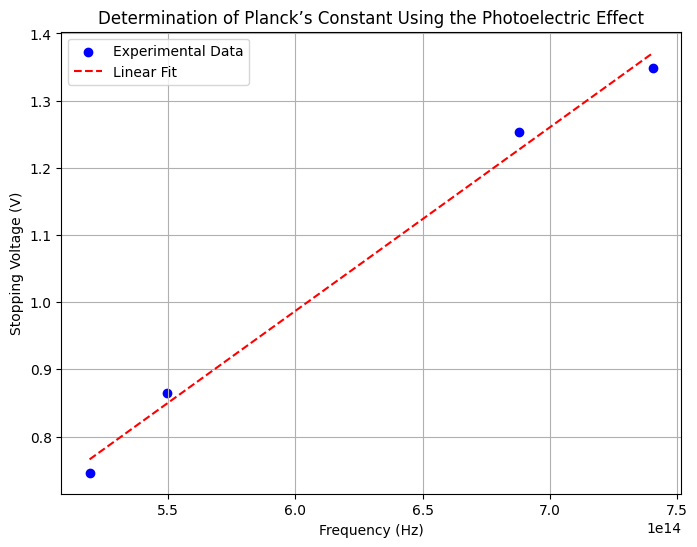

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Constants
SPEED_OF_LIGHT = 3 * 10**8  # m/s
ELECTRON_CHARGE = 1.6 * 10**(-19)  # C

def load_experimental_data(filename):
    """
    Load experimental data from a CSV file and process it.

    Parameters:
        filename (str): Path to the CSV file.

    Returns:
        tuple: Arrays of wavelengths (m) and mean stopping voltages (V).
    """
    data = np.genfromtxt(filename, delimiter=',', dtype=str)

    # Remove headers
    data = np.delete(data, 0, axis=0)
    data = np.delete(data, 0, axis=1)

    # Extract wavelength data and convert from nm to meters
    wavelengths = data[:, 0].astype(float) * 10**(-9)

    # Remove wavelength column from the dataset
    voltage_data = np.delete(data, 0, axis=1).astype(float)

    # Convert from millivolts (mV) to volts (V)
    voltage_data /= 1000

    # Compute mean stopping voltages
    mean_voltage = np.mean(voltage_data, axis=1)

    # Keep only the visible spectrum data (removing ultraviolet values)
    wavelengths, mean_voltage = wavelengths[:4], mean_voltage[:4]

    return wavelengths, mean_voltage

def compute_frequencies(wavelengths):
    """
    Compute frequencies corresponding to given wavelengths.

    Parameters:
        wavelengths (array): Wavelength values in meters.

    Returns:
        array: Frequency values in Hz.
    """
    return SPEED_OF_LIGHT / wavelengths

def perform_linear_regression(frequencies, voltages):
    """
    Perform linear regression on stopping voltage vs frequency data.

    Parameters:
        frequencies (array): Frequency values in Hz.
        voltages (array): Stopping voltage values in V.

    Returns:
        tuple: Trained linear regression model and estimated Planck’s constant (h).
    """
    model = LinearRegression().fit(frequencies.reshape(-1, 1), voltages)

    # Compute experimental Planck’s constant (h = slope * e)
    h_experimental = model.coef_[0] * ELECTRON_CHARGE

    return model, h_experimental

def plot_results(frequencies, voltages, model):
    """
    Plot the experimental data and linear fit.

    Parameters:
        frequencies (array): Frequency values in Hz.
        voltages (array): Stopping voltage values in V.
        model (LinearRegression): Trained regression model.
    """
    plt.figure(figsize=(8, 6))
    plt.scatter(frequencies, voltages, color='blue', label='Experimental Data')
    plt.plot(frequencies, model.predict(frequencies.reshape(-1, 1)), color='red', linestyle='dashed', label='Linear Fit')

    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Stopping Voltage (V)')
    plt.title("Determination of Planck’s Constant Using the Photoelectric Effect")
    plt.legend()
    plt.grid()
    plt.show()

def main():
    """Main function to process and analyze the photoelectric effect data."""

    # Load and process experimental data
    wavelengths, stopping_voltages = load_experimental_data('data/values.csv')

    # Compute frequencies
    frequencies = compute_frequencies(wavelengths)

    # Perform linear regression
    model, h_experimental = perform_linear_regression(frequencies, stopping_voltages)

    # Compute the x-intercept (threshold frequency)
    threshold_frequency = -model.intercept_ / model.coef_[0]

    # Print results
    print("\n--- Planck’s Constant Determination ---")
    print(f"Experimental Planck’s Constant (h): {h_experimental:.3e} J·s")
    print(f"Threshold Frequency (ν_p): {threshold_frequency:.3e} Hz")

    # Plot results
    plot_results(frequencies, stopping_voltages, model)

if __name__ == '__main__':
    main()
